✓ XGBoost is available
✓ LIGHTGBM is available

--- Iniciando preparación de datos (Dataset: ../../data/mixed_population_dataset_160_households_more_leaks.csv) ---
   -> Datos cargados: 2,764,800 filas. Iniciando Feature Engineering...
   -> Split realizado. Train: 2,211,840, Test: 552,960
   -> Escalando datos...
✓ Datos preparados en 4.6 segundos.

--- Entrenando Isolation Forest ---
   Evaluando Isolation Forest...

--- Entrenando Extended Isolation Forest (Isotree) ---

--- Entrenando Random Forest ---
   Evaluando Random Forest...

--- Entrenando XGBoost ---
   Evaluando XGBoost...

--- Entrenando LightGBM ---
   Evaluando LightGBM...

✓ Gráfico guardado en model_benchmark.png

✅ Benchmark Finalizado.


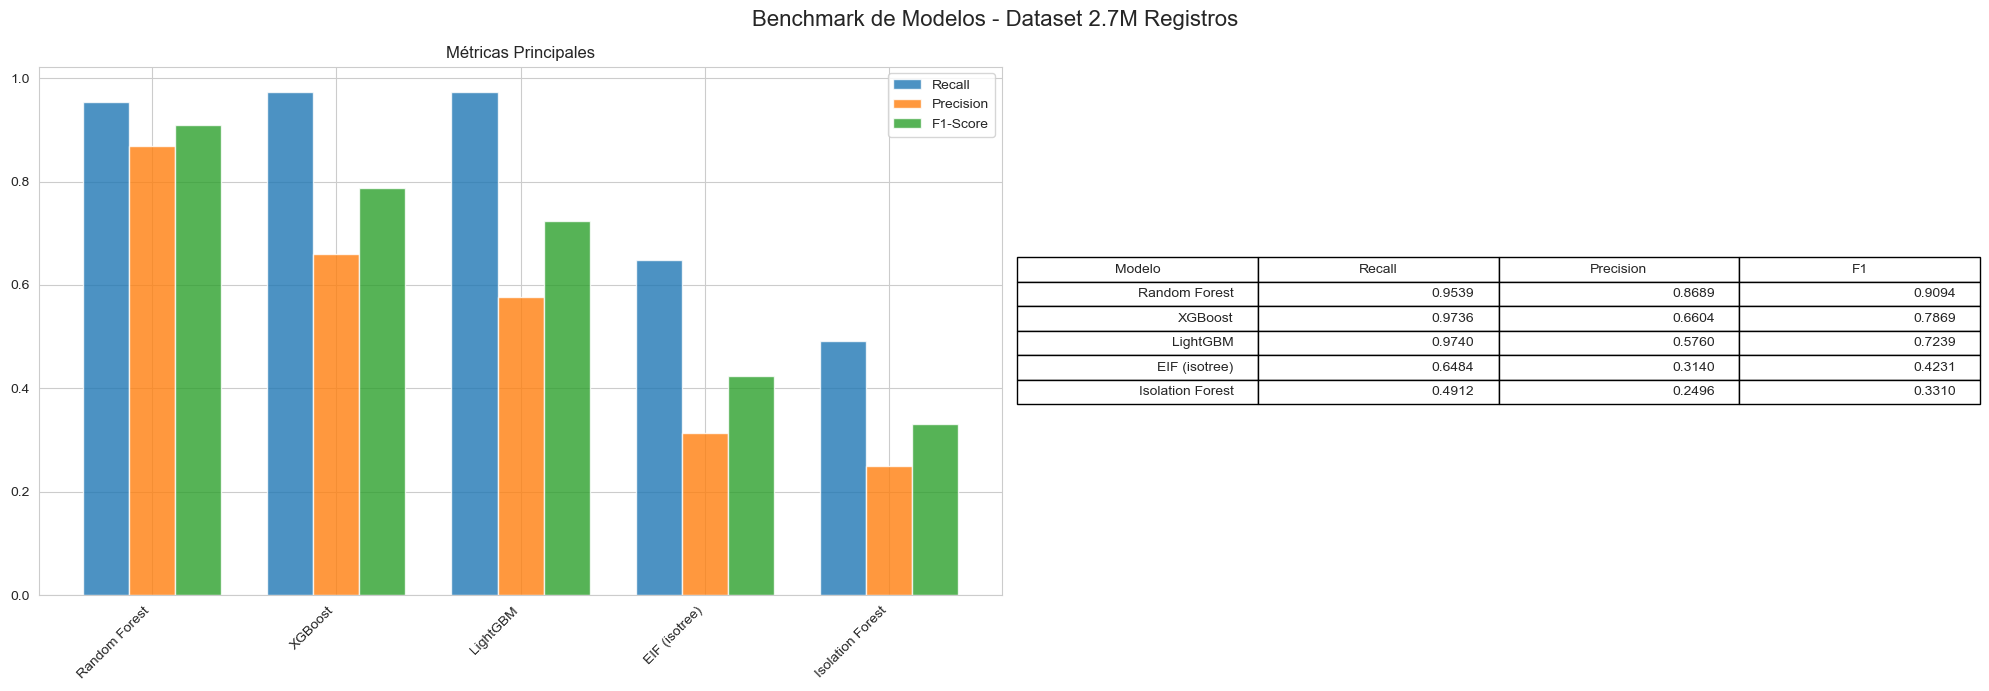

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time # Añadido para medir tiempos
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import(
    classification_report, recall_score, precision_score, f1_score, roc_auc_score
)

# Models
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from isotree import IsolationForest as EIForest

# Optional libraries check
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost is available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("X XGBoost is NOT available")

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
    print("✓ LIGHTGBM is available")
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("X LIGHTGBM is NOT available")

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15,7)

# --- 1. PREPARACIÓN DE DATOS ---
def prepare_data(data_path):
    print(f"\n--- Iniciando preparación de datos (Dataset: {data_path}) ---")
    start_time = time.time()
    
    # Carga optimizada
    df = pd.read_csv(data_path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    print(f"   -> Datos cargados: {len(df):,} filas. Iniciando Feature Engineering...")
    
    # Feature Engineering
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    
    df = df.sort_values(['household_id', 'timestamp']).reset_index(drop=True)
    
    # Rolling windows (Esto es lo que más tarda)
    window_sizes = [4, 8, 24]
    grouped = df.groupby('household_id')['consumption_l']
    
    for window in window_sizes:
        # Usamos transform directamente para velocidad
        rolling = grouped.rolling(window=window, min_periods=1)
        df[f'rolling_mean_{window}'] = rolling.mean().reset_index(level=0, drop=True)
        df[f'rolling_std_{window}'] = rolling.std().reset_index(level=0, drop=True)
        df[f'rolling_cv_{window}'] = df[f'rolling_std_{window}'] / (df[f'rolling_mean_{window}'] + 1e-6)
        
    df.fillna(0, inplace=True)
    
    feature_cols = [
        'consumption_l', 'hour', 'day_of_week', 'is_weekend',
        'rolling_mean_4', 'rolling_std_4', 'rolling_cv_4',
        'rolling_mean_8', 'rolling_std_8', 'rolling_cv_8',
        'rolling_mean_24', 'rolling_std_24', 'rolling_cv_24'
    ]
    target = 'is_leak'
    
    # Split Cronológico (80/20)
    # Importante: Ordenar por timestamp global para simular producción
    df = df.sort_values('timestamp')
    split_point = int(len(df) * 0.8)
    
    X_train = df.iloc[:split_point][feature_cols]
    y_train = df.iloc[:split_point][target]
    X_test = df.iloc[split_point:][feature_cols]
    y_test = df.iloc[split_point:][target]
    
    print(f"   -> Split realizado. Train: {len(X_train):,}, Test: {len(X_test):,}")
    print("   -> Escalando datos...")
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"✓ Datos preparados en {time.time() - start_time:.1f} segundos.")
    return X_train, X_train_scaled, X_test, X_test_scaled, y_train, y_test, scaler, feature_cols

# --- 2. EVALUACIÓN ---
def evaluate_model(model, X_test, y_test, model_name, is_unsupervised=False):
    print(f"   Evaluando {model_name}...")
    if is_unsupervised:
        y_pred = model.predict(X_test)
        y_pred_mapped = np.where(y_pred == -1, 1, 0)
    else:
        y_pred_mapped = model.predict(X_test)

    results = {
        'model_name': model_name,
        'recall': recall_score(y_test, y_pred_mapped),
        'precision': precision_score(y_test, y_pred_mapped, zero_division=0),
        'f1': f1_score(y_test, y_pred_mapped, zero_division=0),
        'auc': None
    }
    
    if not is_unsupervised and hasattr(model, 'predict_proba'):
        try:
            y_pred_proba = model.predict_proba(X_test)[:, 1]
            results['auc'] = roc_auc_score(y_test, y_pred_proba)
        except: pass
    
    return results

# --- 3. ENTRENAMIENTO DE MODELOS ---

def train_isolation_forest(X_train, X_test, y_test):
    print(f"\n--- Entrenando Isolation Forest ---")
    # Aumentamos n_jobs para paralelizar
    model = IsolationForest(n_estimators=100, contamination=0.03, random_state=42, n_jobs=-1)
    model.fit(X_train)
    return evaluate_model(model, X_test, y_test, "Isolation Forest", is_unsupervised=True)

def train_random_forest(X_train, X_test, y_train, y_test):
    print(f"\n--- Entrenando Random Forest ---")
    # Limitamos max_depth para que no tarde una eternidad con 2M datos
    model = RandomForestClassifier(n_estimators=50, max_depth=15, class_weight="balanced", random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    return evaluate_model(model, X_test, y_test, "Random Forest", is_unsupervised=False)

def train_xgboost(X_train, X_test, y_train, y_test):
    if not XGBOOST_AVAILABLE: return None
    print(f"\n--- Entrenando XGBoost ---")
    scale_pos = (len(y_train) - y_train.sum()) / y_train.sum()
    model = xgb.XGBClassifier(n_estimators=100, max_depth=8, learning_rate=0.1, scale_pos_weight=scale_pos, n_jobs=-1, verbosity=0)
    model.fit(X_train, y_train)
    return evaluate_model(model, X_test, y_test, "XGBoost", is_unsupervised=False)

def train_lightgbm(X_train, X_test, y_train, y_test):
    if not LIGHTGBM_AVAILABLE: return None
    print(f"\n--- Entrenando LightGBM ---")
    scale_pos = (len(y_train) - y_train.sum()) / y_train.sum()
    model = lgb.LGBMClassifier(n_estimators=100, max_depth=8, learning_rate=0.1, scale_pos_weight=scale_pos, n_jobs=-1, verbose=-1)
    model.fit(X_train, y_train)
    return evaluate_model(model, X_test, y_test, "LightGBM", is_unsupervised=False)

def train_isotree(X_train, X_test, y_test):
    print(f"\n--- Entrenando Extended Isolation Forest (Isotree) ---")
    model = EIForest(ntrees=100, nthreads=-1, ndim=1)
    model.fit(X_train)
    scores = model.predict(X_train)
    threshold = np.percentile(scores, 97) # Contamination 3%
    
    test_scores = model.predict(X_test)
    y_pred = (test_scores > threshold).astype(int)
    
    return {
        'model_name': 'EIF (isotree)',
        'recall': recall_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'auc': None
    }

def plot_comparison(results_list, output_path='model_benchmark.png'):
    results_df = pd.DataFrame(results_list).sort_values('f1', ascending=False)
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    fig.suptitle('Benchmark de Modelos - Dataset 2.7M Registros', fontsize=16)
    
    x = np.arange(len(results_df))
    width = 0.25
    axes[0].bar(x - width, results_df['recall'], width, label='Recall', alpha=0.8)
    axes[0].bar(x, results_df['precision'], width, label='Precision', alpha=0.8)
    axes[0].bar(x + width, results_df['f1'], width, label='F1-Score', alpha=0.8)
    axes[0].set_xticks(x); axes[0].set_xticklabels(results_df['model_name'], rotation=45, ha='right')
    axes[0].legend(); axes[0].set_title('Métricas Principales')
    
    # Tabla
    cell_text = []
    for row in range(len(results_df)):
        cell_text.append([
            results_df.iloc[row]['model_name'],
            f"{results_df.iloc[row]['recall']:.4f}",
            f"{results_df.iloc[row]['precision']:.4f}",
            f"{results_df.iloc[row]['f1']:.4f}"
        ])
    
    axes[1].axis('off')
    table = axes[1].table(cellText=cell_text, colLabels=['Modelo', 'Recall', 'Precision', 'F1'], loc='center')
    table.scale(1, 1.5); table.auto_set_font_size(False); table.set_fontsize(10)
    
    plt.tight_layout()
    plt.savefig(output_path)
    print(f"\n✓ Gráfico guardado en {output_path}")

# ==========================================================
# EJECUCIÓN PRINCIPAL
# ==========================================================
if __name__ == "__main__":
    # 1. RUTA CORRECTA AL NUEVO DATASET
    DATA_PATH = '../../data/mixed_population_dataset_160_households_more_leaks.csv'
    
    # Cargar y preparar
    X_train, X_train_s, X_test, X_test_s, y_train, y_test, _, _ = prepare_data(DATA_PATH)
    
    results = []
    
    # Ejecutar Modelos (LOF DESACTIVADO por rendimiento)
    results.append(train_isolation_forest(X_train_s, X_test_s, y_test))
    results.append(train_isotree(X_train_s, X_test_s, y_test))
    
    # Supervisados
    results.append(train_random_forest(X_train, X_test, y_train, y_test))
    
    # Boosters (si están instalados)
    res_xgb = train_xgboost(X_train, X_test, y_train, y_test)
    if res_xgb: results.append(res_xgb)
        
    res_lgb = train_lightgbm(X_train, X_test, y_train, y_test)
    if res_lgb: results.append(res_lgb)
    
    # Guardar y Pintar
    pd.DataFrame(results).to_csv('benchmark_results.csv', index=False)
    plot_comparison(results)
    
    print("\n✅ Benchmark Finalizado.")